In [1]:
import requests
import json
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#Function to pass year and week to ESPN API
def espn_nfl_sched(year, week):
    # Set base URL
    base_url = "https://cdn.espn.com/core/nfl/"

    # Make API GET request
    r = requests.get(f"{base_url}schedule?xhr=1&year={year}&week={week}")
    result = r.json()

    # Parse schedule data
    # Load the JSON file
    data = result
    
    # Iterate over the 'schedule' to gather the required fields
    for date, details in data['content']['schedule'].items():
        for game in details['games']:
            week = game['week']['number']
            name = game['name']
            
            # Extract competitors and game links
            for competition in game['competitions']:
                for team in competition['competitors']:
                    teamId = team['team']['id']
                    displayName = team['team']['displayName']
                    teamscore = team['score']
                    
                    # Extract gameId from 'links' if available
                    for link in game['links']:
                        if 'gameId=' in link['href']:
                            gameId = link['href'].split('gameId=')[1]
                            parsed_data.append({
                                'year': year,
                                'week': week,
                                'name': name,
                                'teamId': teamId,
                                'displayName': displayName,
                                'gameId': gameId,
                                'teamScore': teamscore
                            })

    return parsed_data


In [3]:
def game_boxscore(gameId):
    #pull game data
    game_url = f"https://cdn.espn.com/core/nfl/boxscore?xhr=1&gameId={gameId}"

    g = requests.get(game_url)
    game = g.json()
    data = game['gamepackageJSON']['boxscore']

    # Extracting data from the teams and their statistics
    for team_info in data['teams']:
        team = team_info['team']['displayName']
        home_away = team_info['homeAway']
        # Create a dictionary for each team and fill it with statistics
        team_stats = {
            'team': team,
            'homeAway': home_away
        }
        for stat in team_info['statistics']:
            stat_name = stat['name']
            stat_value = stat['displayValue']
            team_stats[stat_name] = stat_value
            team_stats['gameID'] = gameId
        
        teams_data.append(team_stats)

    return teams_data


In [4]:
#iterate through current weeks of 2024 season
parsed_data = []
for i in range(1,16):
    season = espn_nfl_sched("2024",i)

In [5]:
schedDF = pd.json_normalize(season)
schedDF = schedDF.drop_duplicates()
schedDF['tabkey_1'] = schedDF['displayName']+schedDF['gameId']
schedDF

,year,week,name,teamId,displayName,gameId,teamScore,tabkey_1
0,2024,1,Baltimore Ravens at Kansas City Chiefs,12,Kansas City Chiefs,401671789,27,Kansas City Chiefs401671789
2,2024,1,Baltimore Ravens at Kansas City Chiefs,33,Baltimore Ravens,401671789,20,Baltimore Ravens401671789
4,2024,1,Green Bay Packers at Philadelphia Eagles,21,Philadelphia Eagles,401671805,34,Philadelphia Eagles401671805
5,2024,1,Green Bay Packers at Philadelphia Eagles,9,Green Bay Packers,401671805,29,Green Bay Packers401671805
6,2024,1,Pittsburgh Steelers at Atlanta Falcons,1,Atlanta Falcons,401671744,10,Atlanta Falcons401671744
...,...,...,...,...,...,...,...,...
531,2024,15,Green Bay Packers at Seattle Seahawks,9,Green Bay Packers,401671796,30,Green Bay Packers401671796
532,2024,15,Chicago Bears at Minnesota Vikings,16,Minnesota Vikings,401671489,30,Minnesota Vikings401671489
534,2024,15,Chicago Bears at Minnesota Vikings,3,Chicago Bears,401671489,12,Chicago Bears401671489
536,2024,15,Atlanta Falcons at Las Vegas Raiders,13,Las Vegas Raiders,401671697,9,Las Vegas Raiders401671697


In [6]:
gameIds = schedDF['gameId'].unique().tolist()

In [7]:
teams_data = []
for j in gameIds:
    game_stats = game_boxscore(j)

In [8]:
# Convert to DataFrame
gameDF = pd.DataFrame(game_stats)
gameDF

,team,homeAway,firstDowns,gameID,firstDownsPassing,firstDownsRushing,firstDownsPenalty,thirdDownEff,fourthDownEff,totalOffensivePlays,...,sacksYardsLost,rushingYards,rushingAttempts,yardsPerRushAttempt,redZoneAttempts,totalPenaltiesYards,turnovers,fumblesLost,defensiveTouchdowns,possessionTime
0,Baltimore Ravens,away,25,401671789,11,13,1,7-14,1-2,74,...,1-6,185,32,5.8,1-4,7-64,1,1,0,33:43
1,Kansas City Chiefs,home,21,401671789,15,4,2,4-9,0-0,50,...,2-10,72,20,3.6,1-3,6-45,1,0,0,26:17
2,Green Bay Packers,away,19,401671805,9,7,3,3-11,1-1,58,...,2-9,163,21,7.8,1-4,10-71,1,0,0,27:13
3,Philadelphia Eagles,home,25,401671805,14,8,3,4-14,1-1,74,...,2-12,144,38,3.8,3-6,7-57,3,1,0,32:47
4,Pittsburgh Steelers,away,16,401671744,6,9,1,8-17,0-1,66,...,2-23,137,41,3.3,0-2,9-60,0,0,0,35:36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,Seattle Seahawks,home,14,401671796,7,5,2,4-13,0-0,56,...,7-45,80,16,5.0,0-1,5-108,2,0,0,27:02
440,Chicago Bears,away,16,401671489,8,7,1,1-12,1-3,63,...,2-25,113,29,3.9,1-3,9-93,1,1,0,30:06
441,Minnesota Vikings,home,24,401671489,14,8,2,7-14,0-1,71,...,2-16,114,29,3.9,3-4,10-56,1,0,0,29:54
442,Atlanta Falcons,away,14,401671697,6,7,1,4-13,0-0,57,...,3-19,168,37,4.5,0-0,6-30,1,0,0,33:52


In [9]:
for col in schedDF.columns:
    print(col)

year
week
name
teamId
displayName
gameId
teamScore
tabkey_1


In [10]:
parsedGameDF = gameDF[['team', 'gameID', 'totalYards', 'netPassingYards', 'sacksYardsLost', 'rushingYards', 'defensiveTouchdowns']]
parsedGameDF['tabkey_2'] = parsedGameDF['team']+parsedGameDF['gameID']
parsedGameDF

/tmp/ipykernel_2312/2242153986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parsedGameDF['tabkey_2'] = parsedGameDF['team']+parsedGameDF['gameID']


,team,gameID,totalYards,netPassingYards,sacksYardsLost,rushingYards,defensiveTouchdowns,tabkey_2
0,Baltimore Ravens,401671789,452,267,1-6,185,0,Baltimore Ravens401671789
1,Kansas City Chiefs,401671789,353,281,2-10,72,0,Kansas City Chiefs401671789
2,Green Bay Packers,401671805,414,251,2-9,163,0,Green Bay Packers401671805
3,Philadelphia Eagles,401671805,410,266,2-12,144,0,Philadelphia Eagles401671805
4,Pittsburgh Steelers,401671744,270,133,2-23,137,0,Pittsburgh Steelers401671744
...,...,...,...,...,...,...,...,...
439,Seattle Seahawks,401671796,208,128,7-45,80,0,Seattle Seahawks401671796
440,Chicago Bears,401671489,284,171,2-25,113,0,Chicago Bears401671489
441,Minnesota Vikings,401671489,329,215,2-16,114,0,Minnesota Vikings401671489
442,Atlanta Falcons,401671697,261,93,3-19,168,0,Atlanta Falcons401671697


In [11]:
df = pd.merge(schedDF, parsedGameDF, how="left", left_on="tabkey_1", right_on = "tabkey_2")

In [12]:
df =  df[["year", "week", "name", "teamId", "team", "gameId", "teamScore", "totalYards", "netPassingYards", "sacksYardsLost", "rushingYards", "defensiveTouchdowns"]]
df

,year,week,name,teamId,team,gameId,teamScore,totalYards,netPassingYards,sacksYardsLost,rushingYards,defensiveTouchdowns
0,2024,1,Baltimore Ravens at Kansas City Chiefs,12,Kansas City Chiefs,401671789,27,353,281,2-10,72,0
1,2024,1,Baltimore Ravens at Kansas City Chiefs,33,Baltimore Ravens,401671789,20,452,267,1-6,185,0
2,2024,1,Green Bay Packers at Philadelphia Eagles,21,Philadelphia Eagles,401671805,34,410,266,2-12,144,0
3,2024,1,Green Bay Packers at Philadelphia Eagles,9,Green Bay Packers,401671805,29,414,251,2-9,163,0
4,2024,1,Pittsburgh Steelers at Atlanta Falcons,1,Atlanta Falcons,401671744,10,226,137,2-18,89,0
...,...,...,...,...,...,...,...,...,...,...,...,...
439,2024,15,Green Bay Packers at Seattle Seahawks,9,Green Bay Packers,401671796,30,369,229,0-0,140,0
440,2024,15,Chicago Bears at Minnesota Vikings,16,Minnesota Vikings,401671489,30,329,215,2-16,114,0
441,2024,15,Chicago Bears at Minnesota Vikings,3,Chicago Bears,401671489,12,284,171,2-25,113,0
442,2024,15,Atlanta Falcons at Las Vegas Raiders,13,Las Vegas Raiders,401671697,9,249,184,4-24,65,0


In [13]:
df = df.astype({"teamScore": int, "defensiveTouchdowns": int, "totalYards": float})
df["defScore"] = df["defensiveTouchdowns"]*6
df["netScore"] = df["teamScore"] - df["defScore"]
df["expectedScores"] = (df["totalYards"]/71.2).apply(np.floor)
df["maxExpectedPoints"] = df["expectedScores"]*8
df["minExpectedPoints"] = df["expectedScores"]*3
df["offEff"] = df["netScore"]/df["maxExpectedPoints"]
df["minOff"] = df["minExpectedPoints"]/df["maxExpectedPoints"]
df["maxOff"] = df["maxExpectedPoints"]/df["maxExpectedPoints"]
df

,year,week,name,teamId,team,gameId,teamScore,totalYards,netPassingYards,sacksYardsLost,rushingYards,defensiveTouchdowns,defScore,netScore,expectedScores,maxExpectedPoints,minExpectedPoints,offEff,minOff,maxOff
0,2024,1,Baltimore Ravens at Kansas City Chiefs,12,Kansas City Chiefs,401671789,27,353.0,281,2-10,72,0,0,27,4.0,32.0,12.0,0.843750,0.375,1.0
1,2024,1,Baltimore Ravens at Kansas City Chiefs,33,Baltimore Ravens,401671789,20,452.0,267,1-6,185,0,0,20,6.0,48.0,18.0,0.416667,0.375,1.0
2,2024,1,Green Bay Packers at Philadelphia Eagles,21,Philadelphia Eagles,401671805,34,410.0,266,2-12,144,0,0,34,5.0,40.0,15.0,0.850000,0.375,1.0
3,2024,1,Green Bay Packers at Philadelphia Eagles,9,Green Bay Packers,401671805,29,414.0,251,2-9,163,0,0,29,5.0,40.0,15.0,0.725000,0.375,1.0
4,2024,1,Pittsburgh Steelers at Atlanta Falcons,1,Atlanta Falcons,401671744,10,226.0,137,2-18,89,0,0,10,3.0,24.0,9.0,0.416667,0.375,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,2024,15,Green Bay Packers at Seattle Seahawks,9,Green Bay Packers,401671796,30,369.0,229,0-0,140,0,0,30,5.0,40.0,15.0,0.750000,0.375,1.0
440,2024,15,Chicago Bears at Minnesota Vikings,16,Minnesota Vikings,401671489,30,329.0,215,2-16,114,0,0,30,4.0,32.0,12.0,0.937500,0.375,1.0
441,2024,15,Chicago Bears at Minnesota Vikings,3,Chicago Bears,401671489,12,284.0,171,2-25,113,0,0,12,3.0,24.0,9.0,0.500000,0.375,1.0
442,2024,15,Atlanta Falcons at Las Vegas Raiders,13,Las Vegas Raiders,401671697,9,249.0,184,4-24,65,0,0,9,3.0,24.0,9.0,0.375000,0.375,1.0


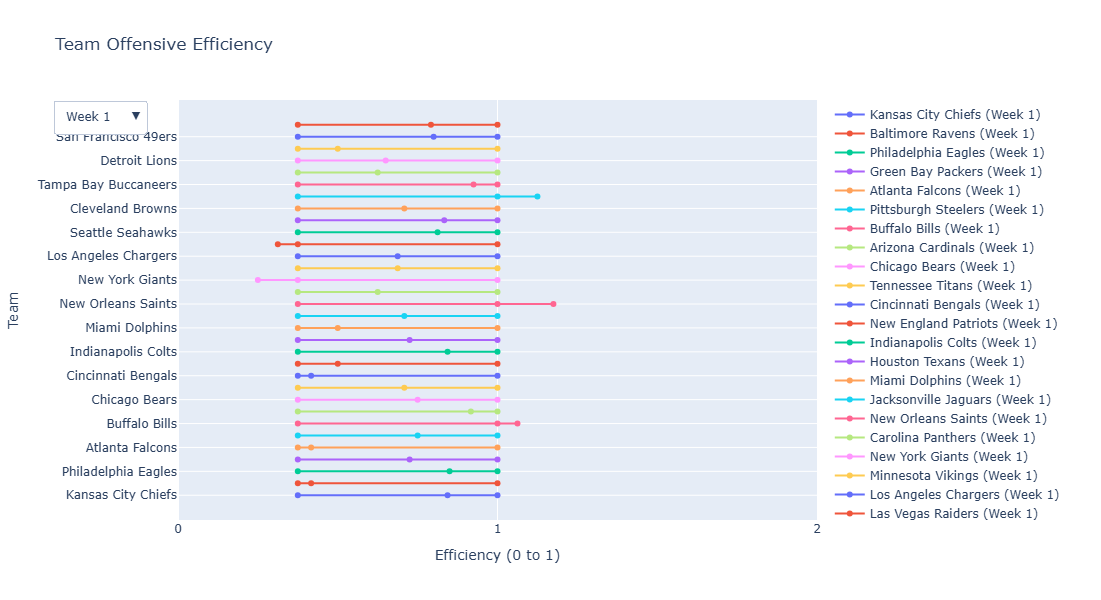

In [17]:
# Create the plotly figure
def create_plot(selected_week):
    filtered_df = df[df['week'] == selected_week]
    fig = make_subplots(specs=[[{"secondary_y": False}]])

    for i, row in filtered_df.iterrows():
        fig.add_trace(
            go.Scatter(
                x=[row['minOff'], row['offEff'], row['maxOff']],
                y=[row['team'], row['team'], row['team']],
                mode='lines+markers',
                name=row['team'],
                hovertemplate=f"<b>{row['team']}</b><br>Min: {row['minOff']}<br>Eff: {row['offEff']}<br>Max: {row['maxOff']}<extra></extra>",
            )
        )

    fig.update_layout(
        title=f"Team Offensive Efficiency (Week {selected_week})",
        xaxis_title="Efficiency (0 to 1)",
        yaxis_title="Team",
        xaxis=dict(range=[0, 2], tickmode='linear'),
        yaxis=dict(type='category'),
        height=600,
    )
    return fig

# Create a dropdown selector
week_options = df['week'].unique()

fig = go.Figure()

for week in week_options:
    filtered_df = df[df['week'] == week]
    for i, row in filtered_df.iterrows():
        fig.add_trace(
            go.Scatter(
                x=[row['minOff'], row['offEff'], row['maxOff']],
                y=[row['team'], row['team'], row['team']],
                mode='lines+markers',
                name=f"{row['team']} (Week {week})",
                visible=(week == week_options[0]),
                hovertemplate=f"<b>{row['team']}</b><br>Min: {row['minOff']}<br>Eff: {row['offEff']}<br>Max: {row['maxOff']}<extra></extra>",
            )
        )

fig.update_layout(
    title="Team Offensive Efficiency",
    xaxis_title="Efficiency (0 to 1)",
    yaxis_title="Team",
    xaxis=dict(range=[0, 2], tickmode='linear'),
    yaxis=dict(type='category'),
    height=600,
    updatemenus=[
        {
            "buttons": [
                {
                    "label": f"Week {week}",
                    "method": "update",
                    "args": [
                        {"visible": [trace.name.endswith(f"(Week {week})") for trace in fig.data]},
                        {"title": f"Team Offensive Efficiency (Week {week})"},
                    ],
                }
                for week in week_options
            ],
            "direction": "down",
            "showactive": True,
        }
    ]
)

fig.show()